# Exploration and Data Loading

In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading Data
df  = pd.read_csv("googleplaystore.csv")
# Checking the dimension of the data
df.shape

(10841, 13)

In [4]:
# Viewing the first 5 rows
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [6]:
# Descriptive Statistics for Numerical Columns
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
df.describe(include="all")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning & Preprocessing

In [8]:
# Check duplicate values
print(df.duplicated().sum())

483


In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [10]:
# Converting "Installs", "Reviews" and "Price" columns to numeric
df["Installs"] = pd.to_numeric(df["Installs"].str.replace("[+,]", "", regex=True), errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"].str.replace("[+,]", "", regex=True), errors="coerce")
df["Price"] = pd.to_numeric(df["Price"].str.replace("$", "", regex=False), errors="coerce")

In [11]:
# Handling "Varies with device" in Size, Current Ver and Android Ver
df["Size"] = df["Size"].replace("Varies with device", np.nan)
df["Current Ver"] = df["Current Ver"].replace("Varies with device", np.nan)
df["Android Ver"] = df["Android Ver"].replace("Varies with device", np.nan)

In [12]:
def convert_size(size):
    if 'M' in str(size):
        return float(size.replace('M', ''))
    elif 'k' in str(size):
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)

In [13]:
# Check for missing values
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              1
Size              1527
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver       1310
Android Ver       1224
dtype: int64

In [14]:
# Drop missing values in "Rating"
df.dropna(subset=["Rating"], inplace=True)

# Forward fill remaining missing values
df.ffill(inplace=True)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",1.2.4,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7.0,2.6,500.0,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38.0,53.0,5000.0,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4.0,3.6,100.0,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114.0,3.6,1000.0,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",1.0,4.1 and up


In [15]:
# Defining "App Success" column based on "Installs" threshold
# df['App Success'] = (df['Installs'] >= 1000000).astype(int)

#### Check for Outliers in "Ratings"

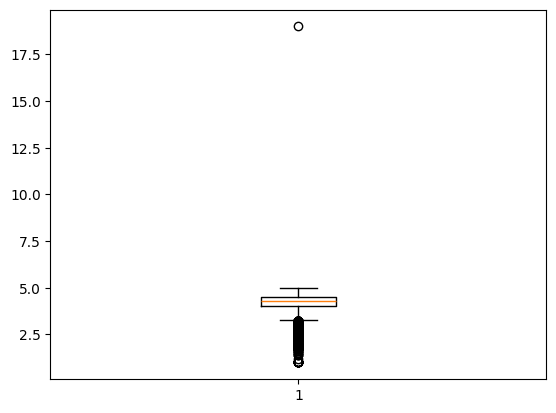

In [16]:
# Visual confirmation
plt.boxplot(df["Rating"])
plt.show()

In [17]:
# Keep only rows where Rating is between 1 and 5
df = df[(df['Rating'] >= 1.0) & (df['Rating'] <= 5.0)]

# Interquartile Range (IQR)
#Q1 = df['Rating'].quantile(0.25)
#Q3 = df['Rating'].quantile(0.75)
#IQR = Q3 - Q1

# Define bounds
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame
#df = df[(df['Rating'] >= lower_bound) & (df['Rating'] <= upper_bound)]

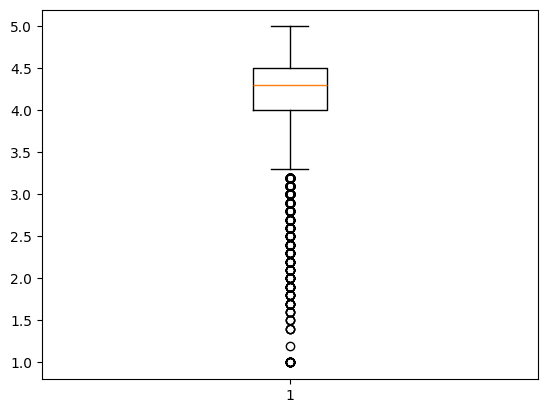

In [18]:
plt.boxplot(df["Rating"])
plt.show()

#### Encoding categorical features

In [19]:
# Binary Encoding (2 unique values)
# Map Free/Paid to 0/1
df["Type"] = df["Type"].replace({
    "Free": 0, "Paid": 1
}).astype(int)

In [20]:
df["Genres"].unique()

<ArrowStringArray>
[               'Art & Design',   'Art & Design;Pretend Play',
     'Art & Design;Creativity',             'Auto & Vehicles',
                      'Beauty',           'Books & Reference',
                    'Business',                      'Comics',
           'Comics;Creativity',               'Communication',
 ...
                      'Casino',       'Adventure;Brain Games',
         'Lifestyle;Education', 'Books & Reference;Education',
            'Puzzle;Education',    'Role Playing;Brain Games',
          'Strategy;Education',         'Racing;Pretend Play',
    'Communication;Creativity',         'Strategy;Creativity']
Length: 115, dtype: str

In [21]:
from sklearn.preprocessing import LabelEncoder

# Encoding "Category" and "Content Rating"
le_category = LabelEncoder()
le_content = LabelEncoder()
#le_genres = LabelEncoder()

df['Category'] = le_category.fit_transform(df['Category'])
df['Content Rating'] = le_content.fit_transform(df['Content Rating'])
#df['Genres'] = le_genres.fit_transform(df['Genres'])

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 8892 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8892 non-null   str    
 1   Category        8892 non-null   int64  
 2   Rating          8892 non-null   float64
 3   Reviews         8892 non-null   float64
 4   Size            8892 non-null   float64
 5   Installs        8892 non-null   float64
 6   Type            8892 non-null   int64  
 7   Price           8892 non-null   float64
 8   Content Rating  8892 non-null   int64  
 9   Genres          8892 non-null   str    
 10  Last Updated    8892 non-null   str    
 11  Current Ver     8892 non-null   str    
 12  Android Ver     8892 non-null   str    
dtypes: float64(5), int64(3), str(5)
memory usage: 1.5 MB


#### Exploratory Data Analysis (EDA)

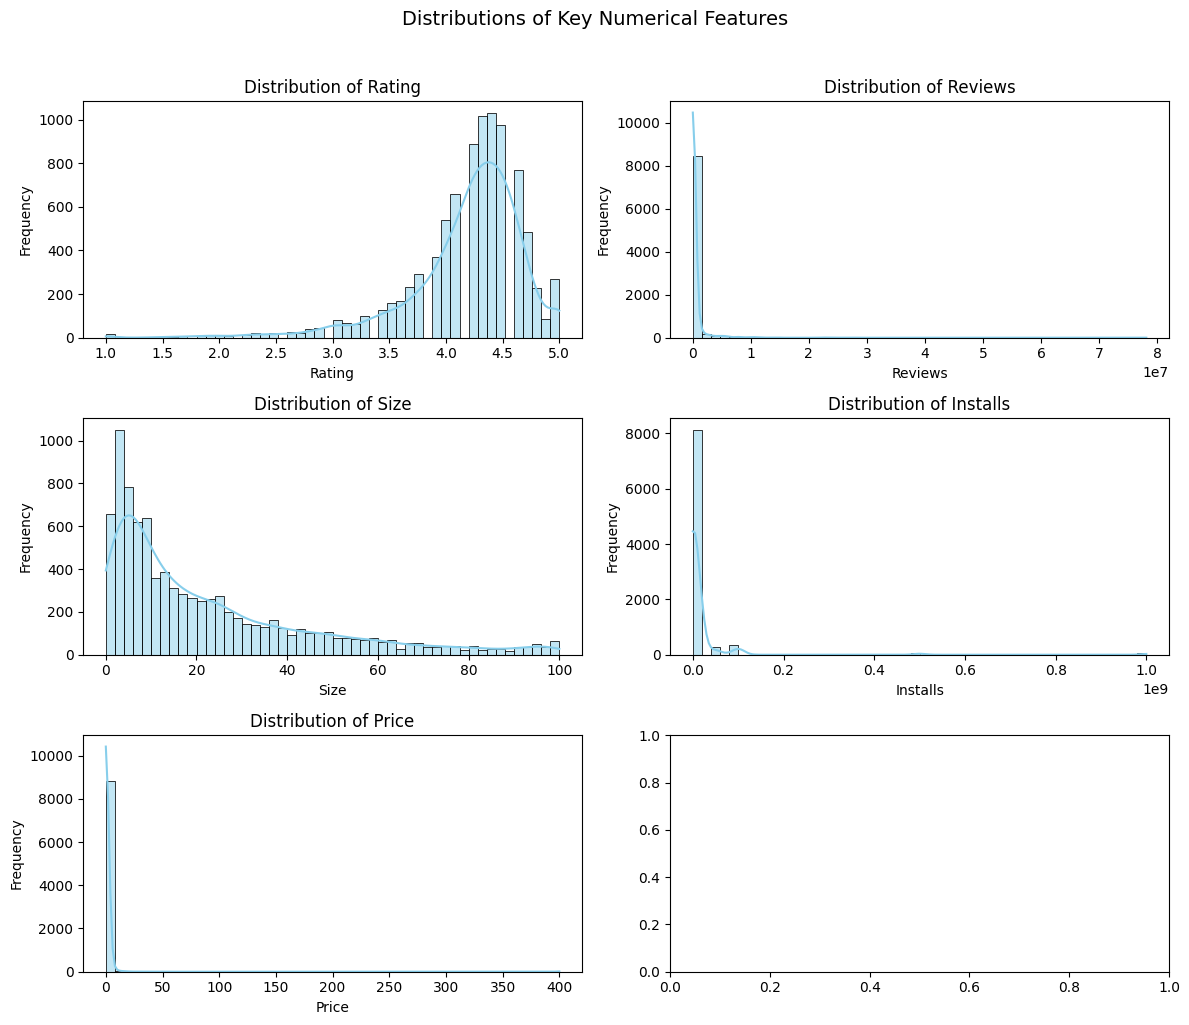

In [23]:
# Distribution Plot

# Select the key numerical features
num_f = ["Rating", "Reviews", "Size", "Installs", "Price"]

# Set up the plotting grid
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each feature distribution
for i, feature in enumerate(num_f):
    sns.histplot(data=df, x=feature, bins=50, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {feature}", fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distributions of Key Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

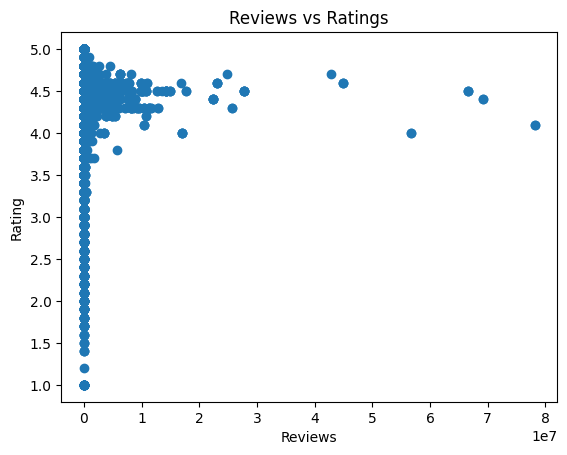

In [24]:
plt.figure()
plt.scatter(df["Reviews"], df["Rating"])
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Ratings")
plt.show()

In [25]:
# Checking the correlation of the features
corr_matrix = df.corr(numeric_only=True)
rating_corr = corr_matrix["Rating"].sort_values(ascending=False)
print(rating_corr)

Rating            1.000000
Size              0.081252
Reviews           0.068732
Installs          0.050886
Type              0.038353
Content Rating    0.026940
Price            -0.022355
Category         -0.037955
Name: Rating, dtype: float64


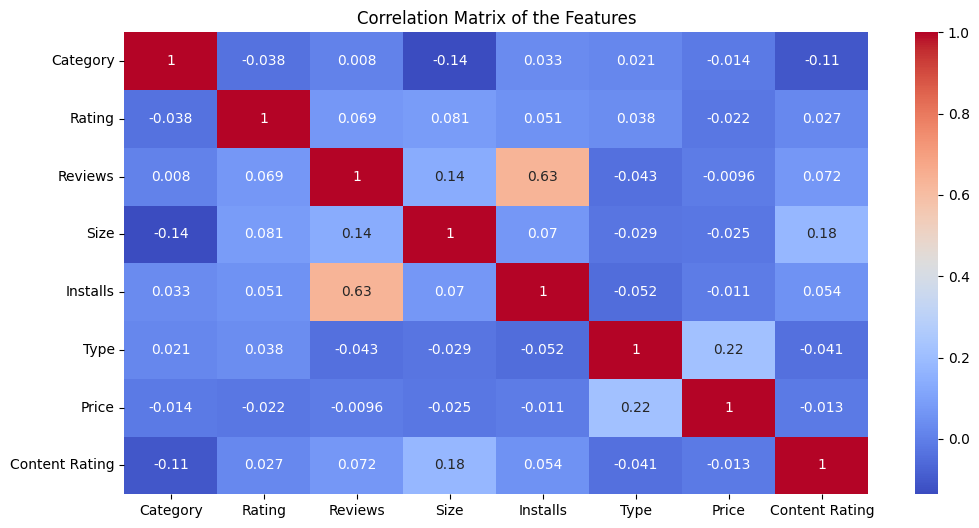

In [26]:
# Plot Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of the Features")
plt.show()

#### Feature Selection

In [27]:
features = ["Category", "Reviews", "Size", "Installs", "Price", "Content Rating"]
X = df[features]
y = df["Rating"]

# Training the ML Model

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(7113, 6) (1779, 6)


In [29]:
# Train Model (Random Forest)
rf = RandomForestRegressor(
    n_estimators=100, 
    random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Evaluation
rf_y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_y_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.32652562300918114
RMSE: 0.4905971044582159


In [31]:
# Check for Overfitting
#print(rf.score(X_train, y_train))
#print(rf.score(X_test, y_test))

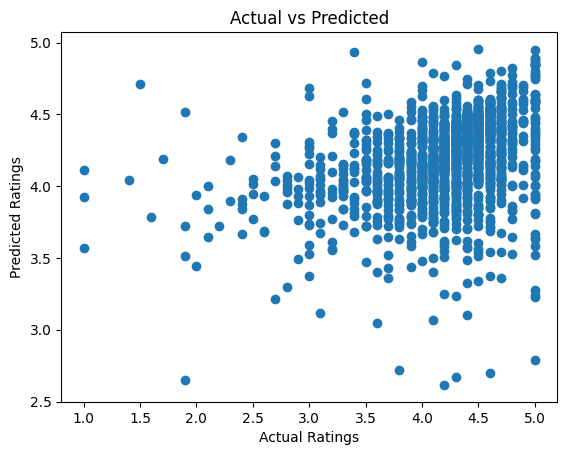

In [32]:
# Plot Actual vs Predicted
plt.scatter(y_test, rf_y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted")
plt.show()

In [33]:
from xgboost import XGBRegressor

# Train Model (XGBoost)
xgb = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [34]:
# Model Evaluation
xgb_y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, xgb_y_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.3294344270276246
RMSE: 0.4927721142467946


#### Hyperparameter Tuning (Optuna)

In [36]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42
    }

    model = RandomForestRegressor(**params)
    
    # Cross-validation
    scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-scores.mean())
    return rmse #minimize RMSE


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, n_jobs=-1)

print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-04-06 22:17:53,626] A new study created in memory with name: no-name-626b0631-87a4-4b98-8113-320650f1d2a5
[I 2026-04-06 22:18:00,651] Trial 5 finished with value: 0.48623129763525896 and parameters: {'n_estimators': 207, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 5 with value: 0.48623129763525896.
[I 2026-04-06 22:18:06,669] Trial 3 finished with value: 0.4838157076968773 and parameters: {'n_estimators': 361, 'max_depth': 29, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.4838157076968773.
[I 2026-04-06 22:18:10,163] Trial 2 finished with value: 0.4853778333411092 and parameters: {'n_estimators': 457, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 3 with value: 0.4838157076968773.
[I 2026-04-06 22:18:11,983] Trial 1 finished with value: 0.4910944343730962 and parameters: {'n_estimators': 539, 'max_depth': 5, 

Best Parameters: {'n_estimators': 547, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2'}
Best RMSE: 0.48314535374997897


#### Train Final Model

In [37]:
best_params = study.best_params
final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",547
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

#### Evaluate Final Model

In [38]:
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final MAE:", mae)
print("Final RMSE:", rmse)
print("R2 Score:", r2)

Final MAE: 0.3223696186263797
Final RMSE: 0.4743733591346516
R2 Score: 0.1446419539457806


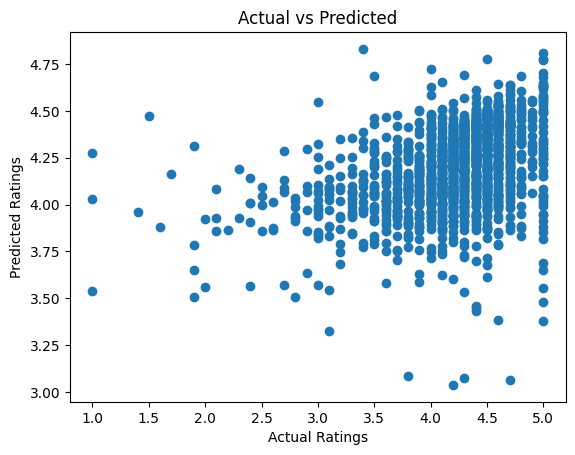

In [39]:
# Plot Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted")
plt.show()

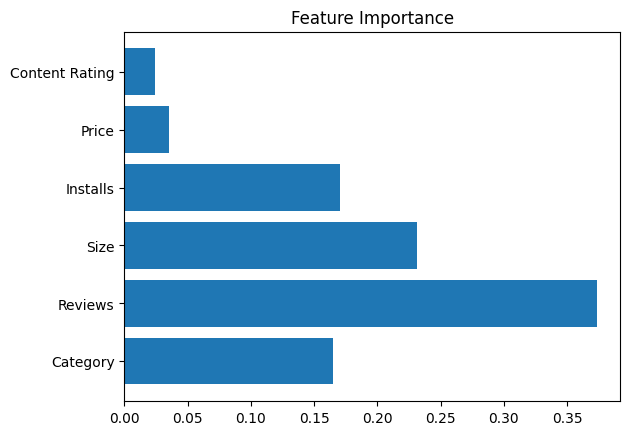

In [40]:
importance = final_model.feature_importances_
feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

# Recommendation System

In [41]:
# Select Features for Similarity
rec_features = df[["Category", "Installs", "Price", "Reviews"]].copy()

In [42]:
from sklearn.preprocessing import StandardScaler

# Normalize Data
scaler = StandardScaler()
rec_scaled = scaler.fit_transform(rec_features)

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute Cosine Similarity
similarity_matrix = cosine_similarity(rec_scaled)

In [44]:
# Recommendation Function
def recommend_app(app_name, df, similarity_matrix):
    try:
        idx = df[df["App"] == app_name].index[0]
        scores = list(enumerate(similarity_matrix[idx]))
        scores = sorted(scores, key=lambda x: x[1], reverse=True)

        recommendations = []
        for i in scores[1:6]:
            recommendations.append(df.iloc[i[0]]["App"])

        return recommendations
    except:
        return ["App not found"]

In [45]:
recommend_app("Colorfit - Drawing & Coloring", df, similarity_matrix)

['Easy Realistic Drawing Tutorial',
 'Sad Poetry Photo Frames 2018',
 'Little Teddy Bear Colouring Book Game',
 'Logo Maker - Small Business',
 'Ai illustrator viewer']

In [46]:
sample = [[2, 50000, 20, 100000, 0, 1]]  # Example input
print("Predicted Rating:", final_model.predict(sample))

Predicted Rating: [4.64662863]


#### Save Model (For Streamlit)

In [47]:
import joblib

joblib.dump(final_model, "model.pkl")
joblib.dump(le_category, "le_category.pkl")
joblib.dump(le_content, "le_content.pkl")

['le_content.pkl']